# Python Notebook End-to-End Walkthrough

This notebook demonstrates setup, execution, state management, data loading, visualization, and reproducibility checks.

## 1. Set Up the Notebook Environment

Create or select a Python kernel, then install/import core libraries.

In [1]:
# If needed, uncomment the next line to install packages in this kernel:
# %pip install numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Environment ready.
NumPy version: 2.4.3
Pandas version: 3.0.1


## 2. Run Basic Python Cells

Run simple cells to verify the execution workflow.

In [2]:
print("Hello from Jupyter!")

# Basic arithmetic
x = 7
y = 5
print("x + y =", x + y)
print("x * y =", x * y)

# Control flow
for i in range(3):
    if i % 2 == 0:
        print(f"{i} is even")
    else:
        print(f"{i} is odd")

Hello from Jupyter!
x + y = 12
x * y = 35
0 is even
1 is odd
2 is even


## 3. Work with Variables and Functions

Define variables and reusable functions, then observe notebook state behavior.

In [3]:
base_value = 10
multiplier = 3


def scale_and_shift(value, scale, shift=0):
    return value * scale + shift

result_a = scale_and_shift(base_value, multiplier)
result_b = scale_and_shift(base_value, multiplier, shift=5)

print("result_a:", result_a)
print("result_b:", result_b)
print("Tip: Change base_value and re-run this cell to see state updates.")

result_a: 30
result_b: 35
Tip: Change base_value and re-run this cell to see state updates.


## 4. Load and Inspect a Dataset

Load a CSV with pandas and inspect its structure and summary statistics.

In [4]:
from pathlib import Path
import json
import os

project_root = Path.cwd()
default_data_dir = project_root / "data"

env_data_dir = os.getenv("DATA_DIR")
local_cfg_path = project_root / "paths.local.json"

if env_data_dir:
    data_dir = Path(env_data_dir).expanduser()
elif local_cfg_path.exists():
    data_dir = Path(json.loads(local_cfg_path.read_text())["data_dir"]).expanduser()
else:
    data_dir = default_data_dir

data_dir.mkdir(parents=True, exist_ok=True)
csv_path = data_dir / "sample_data.csv"

if not csv_path.exists():
    sample_df = pd.DataFrame({
        "day": [1, 2, 3, 4, 5],
        "visits": [120, 135, 128, 150, 160],
        "signups": [12, 16, 14, 18, 21],
    })
    sample_df.to_csv(csv_path, index=False)

df = pd.read_csv(csv_path)

print("Using data directory:", data_dir)
print("Using CSV:", csv_path)
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nHead:")
print(df.head())
print("\nDescribe:")
print(df.describe())
print("\nInfo:")
df.info()

Using data directory: /Users/vitto/Desktop/SP26/DA/project_1/15_Suspicious_Passages/31.Suspicious_Passages
Using CSV: /Users/vitto/Desktop/SP26/DA/project_1/15_Suspicious_Passages/31.Suspicious_Passages/sample_data.csv
Shape: (5, 3)

Dtypes:
day        int64
visits     int64
signups    int64
dtype: object

Head:
   day  visits  signups
0    1     120       12
1    2     135       16
2    3     128       14
3    4     150       18
4    5     160       21

Describe:
            day      visits   signups
count  5.000000    5.000000   5.00000
mean   3.000000  138.600000  16.20000
std    1.581139   16.272676   3.49285
min    1.000000  120.000000  12.00000
25%    2.000000  128.000000  14.00000
50%    3.000000  135.000000  16.00000
75%    4.000000  150.000000  18.00000
max    5.000000  160.000000  21.00000

Info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   day      5 non-n

## 5. Create a Simple Visualization

Build a basic chart and customize labels, title, and figure size.

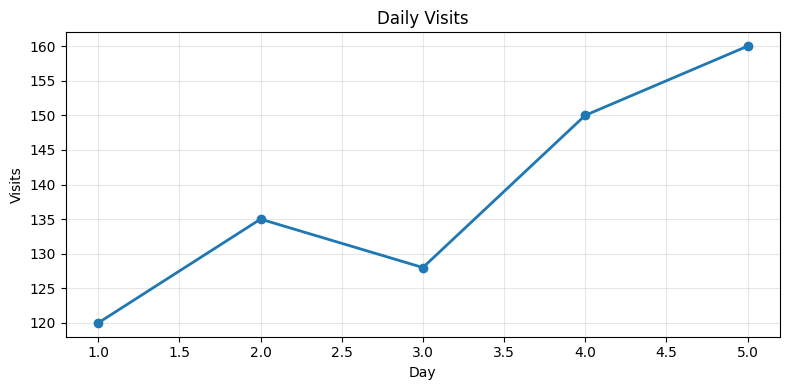

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(df["day"], df["visits"], marker="o", linewidth=2)
plt.title("Daily Visits")
plt.xlabel("Day")
plt.ylabel("Visits")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Save, Restart, and Run All Cells

Use this checklist to validate reproducibility:
1. Save the notebook.
2. Restart the kernel.
3. Run all cells from top to bottom.
4. Confirm outputs regenerate without errors.

In [6]:
# Reproducibility check output
print("Notebook reproducibility check")
print("Rows in dataframe:", len(df))
print("Mean visits:", round(df["visits"].mean(), 2))
print("Function check (scale_and_shift):", scale_and_shift(4, 2, shift=1))
print("If this cell runs after a kernel restart + Run All, the notebook is reproducible.")

Notebook reproducibility check
Rows in dataframe: 5
Mean visits: 138.6
Function check (scale_and_shift): 9
If this cell runs after a kernel restart + Run All, the notebook is reproducible.
